# Chapter 1 — Statistical Paradigms and Core Concepts

**STAT 418 · Computational Data Science** · runnable companion to the
[Chapter 1 webbook](../../Website/part1_foundations/chapter1/index.rst).

Before we can simulate, estimate, or infer, we must answer one question that has
split statisticians for a century: **what does probability *mean*?** Everyone
agrees on the mathematical rules — **Kolmogorov's axioms** — but they disagree
sharply about interpretation, and that disagreement produces genuinely different
inferential machinery. This notebook works the contrast end-to-end on **one real
dataset**: Stephen Curry's 2023-24 free throws, loaded straight from the course
data bucket so every cell runs without the repo.

> **Note.** This is the *slim* Chapter 1. The probability-distribution catalogue
> (PMF/PDF/CDF/quantile) and the Python random-generation tour now live in the
> **appendices** and are not repeated here — this chapter stays on the conceptual
> foundations.

## Learning outcomes
By the end you can:
1. **State** Kolmogorov's three axioms and verify them numerically, deriving the
   complement and inclusion–exclusion rules; explain why the axioms are
   *interpretation-neutral* (the Dutch-book coherence argument).
2. **Distinguish** the frequentist (long-run frequency), Bayesian (degree of
   belief), and likelihood interpretations — and demonstrate each computationally
   (the Law of Large Numbers, Bayes' theorem, the likelihood ratio).
3. **Contrast** frequentist and Bayesian *inference* on the same data: a
   confidence interval vs a credible interval, and what each can and cannot say.
4. **Update** a Bayesian posterior **sequentially** as data arrive, and show the
   answer is order-invariant.
5. **Assess prior sensitivity**: quantify how much a prior moves the posterior via
   the data weight $w = n/(n+n_0)$, and when a strong prior is defensible.

## Section map (mirrors the webbook's single section)
| § | Topic | Concrete demonstration |
|---|-------|------------------------|
| 1.1 | Probability space & Kolmogorov's axioms | fair-die axiom check; Dutch-book coherence |
| 1.2 | Interpretations of probability | LLN coin convergence; medical-diagnosis Bayes update |
| 1.3 | The three inference paradigms, one dataset | Curry 34/36: frequentist CIs vs Bayesian credible interval |
| 1.4 | Sequential Bayesian updating | posterior evolving game-by-game; order invariance |
| 1.5 | Prior sensitivity | four priors $\times$ (early vs full season); $w=n/(n+n_0)$ |
| 1.6 | Likelihood-based inference & the likelihood principle | negative-binomial vs binomial: identical likelihood |
| 1.7 | Summary & connections forward | to Ch 2 (Monte Carlo), Ch 3 (frequentist), Ch 5 (Bayesian) |


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from scipy.special import comb
from statsmodels.stats.proportion import proportion_confint
%matplotlib inline

np.random.seed(418)            # reproducibility (STYLE.md contract)
plt.rcParams.update({
    'figure.figsize': (7.2, 4.2), 'figure.dpi': 110,
    'axes.grid': True, 'grid.alpha': 0.25,
    'axes.spines.top': False, 'axes.spines.right': False,
    'font.size': 11,
})
BLUE, RED, GREEN, ORANGE, PURPLE = '#4C72B0', '#C44E52', '#55A868', '#DD8452', '#8172B3'

# Course data bucket: Chapter 1's real-data spine is the free-throw log in Chapter5.
BASE = ('https://pqyjaywwccbnqpwgeiuv.supabase.co/storage/v1/object/public/'
        'STAT%20418%20Images/Data/Chapter5/')
def url(name):
    return BASE + name

print('environment ready · numpy', np.__version__, '· pandas', pd.__version__)


environment ready · numpy 1.26.4 · pandas 2.3.3


## Section 1.1 — The Probability Space and Kolmogorov's Axioms

All of probability is built on a **probability space** $(\Omega, \mathcal{F}, P)$:
a **sample space** $\Omega$ of all possible outcomes, **events** (subsets of
$\Omega$), and a **probability measure** $P$ obeying **Kolmogorov's three axioms**:

1. **Non-negativity**: $P(E) \ge 0$ for every event $E$.
2. **Normalization**: $P(\Omega) = 1$.
3. **Countable additivity**: for pairwise-disjoint $E_1, E_2, \dots$,
   $P\!\big(\bigcup_i E_i\big) = \sum_i P(E_i)$.

From these three rules *every* familiar property follows — $P(\emptyset)=0$, the
**complement rule** $P(E^c)=1-P(E)$, **inclusion–exclusion**
$P(A\cup B)=P(A)+P(B)-P(A\cap B)$, and monotonicity. Below we encode a discrete
probability space, verify the axioms, and confirm the derived rules on a fair die.


In [2]:
# A discrete probability space that VERIFIES Kolmogorov's axioms on construction.
class DiscreteProbabilitySpace:
    def __init__(self, outcomes, probs, tol=1e-12):
        self.outcomes = list(outcomes)
        self.pmf = dict(zip(self.outcomes, probs))
        # Axiom 1: non-negativity
        for o, p in self.pmf.items():
            if p < 0:
                raise ValueError(f'Axiom 1 violated: P({o}) = {p} < 0')
        # Axiom 2: normalization
        total = sum(self.pmf.values())
        if abs(total - 1.0) > tol:
            raise ValueError(f'Axiom 2 violated: total probability {total} != 1')
    def prob(self, event):
        # event is a set/list of outcomes OR a predicate (callable)
        if callable(event):
            return sum(p for o, p in self.pmf.items() if event(o))
        return sum(self.pmf.get(o, 0.0) for o in event)
    def complement(self, event):
        return 1.0 - self.prob(event)

die = DiscreteProbabilitySpace([1, 2, 3, 4, 5, 6], [1/6]*6)
even = die.prob([2, 4, 6])
gt4  = die.prob(lambda x: x > 4)
print('Fair-die probability space (axioms verified on construction):')
print(f'  P(even)       = {even:.4f}')
print(f'  P(X > 4)      = {gt4:.4f}')
print(f'  P(odd) = 1 - P(even) = {die.complement([2,4,6]):.4f}   (complement rule)')
print(f'  P(even)+P(odd) = {even + die.complement([2,4,6]):.4f}   (normalization)')

# Inclusion-exclusion on overlapping events A = {1,2,3,4}, B = {3,4,5,6}.
A, B = {1, 2, 3, 4}, {3, 4, 5, 6}
incl_excl = die.prob(A) + die.prob(B) - die.prob(A & B)
print(f'  P(A)+P(B)-P(A&B) = {incl_excl:.4f}  vs  P(A|B)=P(A∪B) = {die.prob(A | B):.4f}'
      '   (inclusion-exclusion)')


Fair-die probability space (axioms verified on construction):
  P(even)       = 0.5000
  P(X > 4)      = 0.3333
  P(odd) = 1 - P(even) = 0.5000   (complement rule)
  P(even)+P(odd) = 1.0000   (normalization)
  P(A)+P(B)-P(A&B) = 1.0000  vs  P(A|B)=P(A∪B) = 1.0000   (inclusion-exclusion)


### Why the axioms are interpretation-neutral: the Dutch-book argument

The axioms say *how* probabilities must behave, not *what* they mean — every school
(frequentist, Bayesian, likelihoodist) accepts them. For the **subjective Bayesian**,
the justification that beliefs must obey the axioms is the **Dutch-book argument**:
if your prices for bets violate an axiom, an opponent can build a set of bets that
**guarantees you a loss** regardless of outcome. Below, an agent prices two
*disjoint* events incoherently — $P(A)=0.6$, $P(B)=0.5$, but $P(A\cup B)=0.9$ instead
of the additive $1.1$ — and we show the loss is locked in at $-\$0.20$.


In [3]:
# Incoherent prices for DISJOINT events A, B (additivity demands P(AuB)=1.1, not 0.9).
pA, pB, pAuB = 0.60, 0.50, 0.90
print(f'Stated prices: P(A)={pA}, P(B)={pB}, P(A∪B)={pAuB}'
      f'   (coherent would need P(A∪B)=P(A)+P(B)={pA+pB})')

# The opponent BUYS the A∪B bet from the agent for pAuB, SELLS the A and B bets.
# Agent's upfront cash: +pAuB (received) - pA - pB (paid).
upfront = pAuB - pA - pB
def agent_net(A_occurs, B_occurs):
    cash = upfront
    if A_occurs or B_occurs:   # agent pays $1 on the A∪B bet it sold
        cash -= 1.0
    if A_occurs:               # agent collects $1 on the A bet it bought
        cash += 1.0
    if B_occurs:               # agent collects $1 on the B bet it bought
        cash += 1.0
    return cash

print(f'  upfront cash flow = {upfront:+.2f}')
for name, (a, b) in [('A occurs ', (True, False)),
                     ('B occurs ', (False, True)),
                     ('neither  ', (False, False))]:
    print(f'  {name}: agent net = {agent_net(a, b):+.2f}')
print('  -> a GUARANTEED -$0.20 in every outcome: the Dutch book. Coherent beliefs')
print('     (those obeying the axioms) are exactly the ones that cannot be booked.')


Stated prices: P(A)=0.6, P(B)=0.5, P(A∪B)=0.9   (coherent would need P(A∪B)=P(A)+P(B)=1.1)
  upfront cash flow = -0.20
  A occurs : agent net = -0.20
  B occurs : agent net = -0.20
  neither  : agent net = -0.20
  -> a GUARANTEED -$0.20 in every outcome: the Dutch book. Coherent beliefs
     (those obeying the axioms) are exactly the ones that cannot be booked.


## Section 1.2 — Interpretations of Probability

The axioms are silent on meaning. Two broad camps fill the gap:

* **Objective / frequentist**: $P(E)$ is the **long-run relative frequency** of $E$
  in repeated trials, $P(E)=\lim_{n\to\infty}(\#E \text{ in } n)/n$. Meaningful only
  for repeatable experiments; parameters are fixed constants, not random.
* **Epistemic / Bayesian**: $P(E)$ is a **degree of belief** in a proposition,
  updated by Bayes' theorem. Applies to *any* unknown — a one-time event, a
  hypothesis, a parameter.

We demonstrate each. First the frequentist picture: the **Law of Large Numbers**
guarantees the relative frequency of a biased coin ($p=0.6$) converges to $0.6$, and
the standard error shrinks at the $1/\sqrt{n}$ rate.


In [4]:
# Frequentist interpretation: relative frequency -> true probability (LLN).
rng = np.random.default_rng(42)
p_true, n_max = 0.6, 10_000
flips = rng.binomial(1, p_true, n_max)
n_tr = np.arange(1, n_max + 1)
rel_freq = np.cumsum(flips) / n_tr
se = np.sqrt(p_true * (1 - p_true) / n_tr)

print('Convergence of relative frequency to the true probability p = 0.6:')
print(f'  {"n":>6s} | {"rel.freq":>9s} | {"std.err":>9s} | {"distance":>9s}')
for n in (10, 100, 1000, 10000):
    i = n - 1
    print(f'  {n:6d} | {rel_freq[i]:9.6f} | {se[i]:9.6f} | {abs(rel_freq[i]-p_true):9.6f}')
print('  After 10,000 flips the frequency (0.6048) is within 0.005 of the truth, and')
print('  SE has fallen to ~0.005 -- the LLN in action (still only an APPROXIMATION).')


Convergence of relative frequency to the true probability p = 0.6:
       n |  rel.freq |   std.err |  distance
      10 |  0.400000 |  0.154919 |  0.200000
     100 |  0.600000 |  0.048990 |  0.000000
    1000 |  0.603000 |  0.015492 |  0.003000
   10000 |  0.604800 |  0.004899 |  0.004800
  After 10,000 flips the frequency (0.6048) is within 0.005 of the truth, and
  SE has fallen to ~0.005 -- the LLN in action (still only an APPROXIMATION).


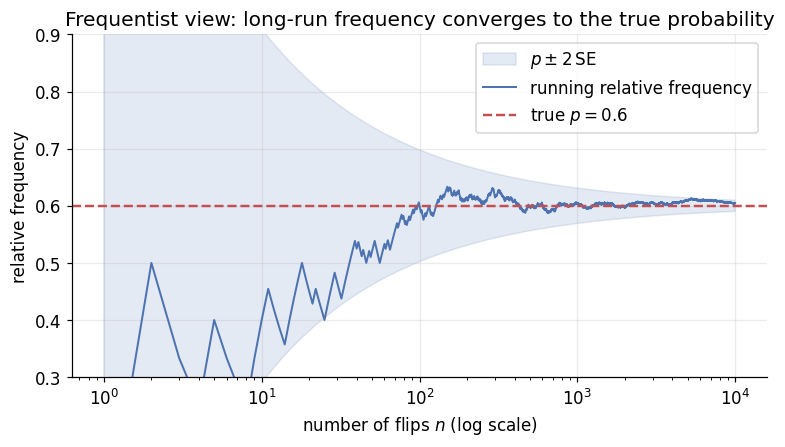

In [5]:
# Figure: the running relative frequency converging onto p = 0.6 with a +/-2 SE band.
fig, ax = plt.subplots()
ax.fill_between(n_tr, p_true - 2*se, p_true + 2*se, color=BLUE, alpha=0.15,
                label=r'$p \pm 2\,\mathrm{SE}$')
ax.plot(n_tr, rel_freq, color=BLUE, lw=1.3, label='running relative frequency')
ax.axhline(p_true, color=RED, lw=1.6, ls='--', label=r'true $p=0.6$')
ax.set_xscale('log')
ax.set_xlabel('number of flips $n$ (log scale)'); ax.set_ylabel('relative frequency')
ax.set_ylim(0.3, 0.9)
ax.set_title('Frequentist view: long-run frequency converges to the true probability')
ax.legend(loc='upper right'); plt.tight_layout(); plt.show()


### The Bayesian picture: update a belief with Bayes' theorem

For the Bayesian, probability is a degree of belief revised by **Bayes' theorem**,
$P(\theta\mid X)\propto P(X\mid\theta)\,P(\theta)$. The classic cautionary tale is
**diagnostic testing**: a rare disease (prevalence $1\%$), a test with $95\%$
sensitivity and $90\%$ specificity. A *positive* test feels alarming — but the
posterior is governed by the low **prior**.


In [6]:
# Bayesian updating: posterior probability of disease given a positive test.
prior, sens, spec = 0.01, 0.95, 0.90
fpr = 1 - spec                              # false-positive rate = 1 - specificity
marg = sens * prior + fpr * (1 - prior)     # P(T+) total probability
post = sens * prior / marg                  # P(D | T+)  Bayes' theorem
print(f'Prior  P(D)            = {prior:.4f}')
print(f'Marginal P(T+)         = {marg:.4f}')
print(f'Posterior P(D | T+)    = {post:.4f}   ({100*post:.2f}%)')
print(f'Bayes factor (evidence) = P(T+|D)/P(T+|Dc) = {sens/fpr:.2f}')
print(f'  prior odds {prior/(1-prior):.4f} x BF {sens/fpr:.2f} = posterior odds '
      f'{post/(1-post):.4f}')
print('  A positive test multiplies the ODDS 9.5x, yet because the disease is rare the')
print('  posterior is still only 8.76% -- the prior matters, and base rates are easy to ignore.')


Prior  P(D)            = 0.0100
Marginal P(T+)         = 0.1085
Posterior P(D | T+)    = 0.0876   (8.76%)
Bayes factor (evidence) = P(T+|D)/P(T+|Dc) = 9.50
  prior odds 0.0101 x BF 9.50 = posterior odds 0.0960
  A positive test multiplies the ODDS 9.5x, yet because the disease is rare the
  posterior is still only 8.76% -- the prior matters, and base rates are easy to ignore.


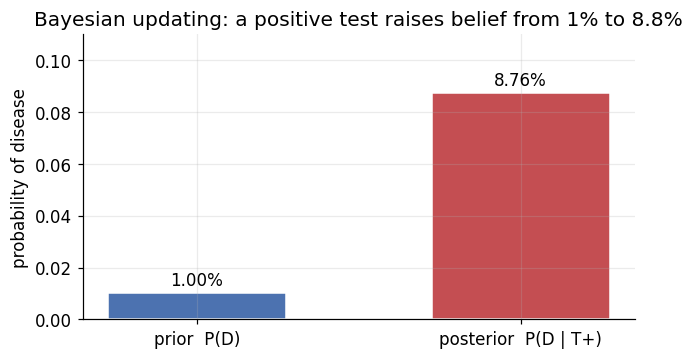

In [7]:
# Figure: how one positive test moves belief (prior 1% -> posterior 8.76%).
fig, ax = plt.subplots(figsize=(6.0, 3.4))
bars = ax.bar(['prior  P(D)', 'posterior  P(D | T+)'], [prior, post],
              color=[BLUE, RED], edgecolor='white', width=0.55)
for b, v in zip(bars, [prior, post]):
    ax.text(b.get_x()+b.get_width()/2, v+0.003, f'{100*v:.2f}%', ha='center', fontsize=11)
ax.set_ylabel('probability of disease'); ax.set_ylim(0, 0.11)
ax.set_title('Bayesian updating: a positive test raises belief from 1% to 8.8%')
plt.tight_layout(); plt.show()


**Read-out.** Same axioms, two readings. The frequentist statement "$P=0.6$" is a
fact about a *repeatable* coin verified by the LLN; the Bayesian statement
"$P(D\mid T^+)=8.76\%$" is a *belief about one patient* produced by Bayes' theorem.
Neither violates Kolmogorov — they answer different questions. A **propensity** view
(probability as a physical single-case tendency) and a **likelihoodist** view
(evidence lives in likelihood ratios, §1.6) round out the landscape. The split below
is what really bites in practice: the two paradigms build **different intervals**.


## Section 1.3 — Frequentist vs Bayesian Inference on Real Data

Interpretation drives inference. We make the contrast concrete on **real free-throw
data**. A free throw is an near-ideal **Bernoulli** trial: fixed distance, no
defender, identical routine — one constant success probability $\theta$ across
exchangeable shots. (Three-pointers would *not* qualify; their difficulty varies shot
to shot.) We take Stephen Curry's **first 36 attempts of 2023-24: 34 makes**
($\hat\theta = 0.944$). Small $n$ is exactly where the paradigms diverge.

* **Frequentist**: $\theta$ is a fixed constant. A 95% **confidence interval** is a
  procedure that traps the truth in 95% of repeated samples. We compute three: the
  **Wald** normal approximation, the **Wilson** score interval, and the exact
  **Clopper–Pearson** interval.
* **Bayesian**: $\theta$ is a random quantity. A flat $\mathrm{Beta}(1,1)$ prior plus
  a Binomial likelihood gives, by conjugacy, a $\mathrm{Beta}(1+k,\,1+n-k)$ posterior
  — here $\mathrm{Beta}(35,3)$ — and a 95% **credible interval** carries a *direct*
  probability statement about $\theta$.


In [8]:
# Real data: Curry's 2023-24 game-by-game free-throw log; take the first >=30 attempts.
ft = pd.read_csv(url('nba_freethrows_2023_24.csv'))
curry = ft[ft['player'] == 'Stephen Curry'].reset_index(drop=True)
early = curry[curry['cum_fta'] >= 30].iloc[0]
k, n = int(early['cum_ft']), int(early['cum_fta'])
phat = k / n
print(f"Curry's first {n} free throws of 2023-24: {k} makes  ->  MLE phat = {phat:.4f}"
      f"  (through game {int(early['game'])}, {early['date']})")

# ---- FREQUENTIST: three 95% confidence intervals ----
z = stats.norm.ppf(0.975)
se = np.sqrt(phat * (1 - phat) / n)
wald = (phat - z*se, min(1.0, phat + z*se))
wilson = proportion_confint(k, n, alpha=0.05, method='wilson')
cp = proportion_confint(k, n, alpha=0.05, method='beta')   # Clopper-Pearson (exact)
print('\nFrequentist 95% confidence intervals (theta is FIXED; the interval is random):')
print(f'  Wald (normal approx) : [{wald[0]:.4f}, {wald[1]:.4f}]   (SE={se:.4f}; clipped at 1)')
print(f'  Wilson (score)       : [{wilson[0]:.4f}, {wilson[1]:.4f}]')
print(f'  Clopper-Pearson exact: [{cp[0]:.4f}, {cp[1]:.4f}]')


Curry's first 36 free throws of 2023-24: 34 makes  ->  MLE phat = 0.9444  (through game 6, 2023-11-03)

Frequentist 95% confidence intervals (theta is FIXED; the interval is random):
  Wald (normal approx) : [0.8696, 1.0000]   (SE=0.0382; clipped at 1)
  Wilson (score)       : [0.8186, 0.9846]
  Clopper-Pearson exact: [0.8134, 0.9932]


In [9]:
# ---- BAYESIAN: conjugate Beta-Binomial update ----
a0, b0 = 1, 1                              # flat Beta(1,1) prior = Uniform(0,1)
a, b = a0 + k, b0 + (n - k)                # add makes to a0, misses to b0 -> Beta(35,3)
posterior = stats.beta(a, b)
mode = (a - 1) / (a + b - 2)
cred = posterior.ppf([0.025, 0.975])       # 95% equal-tailed credible interval
print(f'Bayesian posterior: Beta({a}, {b})   (flat Beta(1,1) prior + {k}/{n})')
print(f'  posterior mean = {posterior.mean():.4f}   mode = {mode:.4f}   sd = {posterior.std():.4f}')
print(f'  95% credible interval: [{cred[0]:.4f}, {cred[1]:.4f}]   (DIRECT prob. statement)')
print(f'  P(theta > 0.90 | data) = {posterior.sf(0.90):.4f}'
      '   <- a question the frequentist cannot answer directly')
print('  Note the posterior is left-skewed (mode 0.944 > mean 0.921): mass piles against 1.')


Bayesian posterior: Beta(35, 3)   (flat Beta(1,1) prior + 34/36)
  posterior mean = 0.9211   mode = 0.9444   sd = 0.0432
  95% credible interval: [0.8181, 0.9830]   (DIRECT prob. statement)
  P(theta > 0.90 | data) = 0.7297   <- a question the frequentist cannot answer directly
  Note the posterior is left-skewed (mode 0.944 > mean 0.921): mass piles against 1.


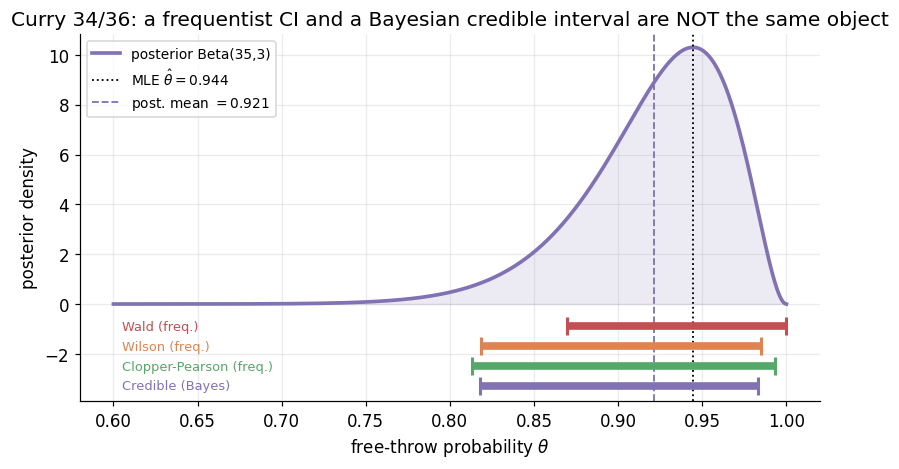

In [10]:
# Figure: the Bayesian posterior density with all four 95% intervals beneath it.
ths = np.linspace(0.6, 1.0, 500)
fig, ax = plt.subplots(figsize=(7.6, 4.4))
ax.plot(ths, posterior.pdf(ths), color=PURPLE, lw=2.4, label=r'posterior Beta(35,3)')
ax.fill_between(ths, posterior.pdf(ths), color=PURPLE, alpha=0.15)
ax.axvline(phat, color='k', ls=':', lw=1.2, label=fr'MLE $\hat\theta={phat:.3f}$')
ax.axvline(posterior.mean(), color=PURPLE, ls='--', lw=1.2,
           label=fr'post. mean $={posterior.mean():.3f}$')

rows = [('Wald (freq.)', wald, RED, -0.9), ('Wilson (freq.)', wilson, ORANGE, -1.7),
        ('Clopper-Pearson (freq.)', cp, GREEN, -2.5), ('Credible (Bayes)', cred, PURPLE, -3.3)]
for name, (lo, hi), col, y in rows:
    ax.plot([lo, hi], [y, y], color=col, lw=5, solid_capstyle='butt')
    ax.plot([lo, hi], [y, y], '|', color=col, ms=12, mew=2)
    ax.text(0.605, y, name, ha='left', va='center', color=col, fontsize=8.5)
ax.set_ylim(-3.9, posterior.pdf(ths).max()*1.05)
ax.set_xlabel(r'free-throw probability $\theta$'); ax.set_ylabel('posterior density')
ax.set_title('Curry 34/36: a frequentist CI and a Bayesian credible interval are NOT the same object')
ax.legend(loc='upper left', fontsize=9); plt.tight_layout(); plt.show()


**Read-out.** The four intervals roughly overlap numerically, but they *mean*
different things. The frequentist intervals (Wald $[0.870,1.000]$ — pinned at the
$1.0$ boundary by the normal approximation — vs the honest Wilson $[0.819,0.985]$ and
exact Clopper–Pearson $[0.813,0.993]$) describe a **procedure**: over many repeated
36-shot samples, 95% of such intervals would trap the fixed $\theta$. The Bayesian
$[0.818,0.983]$ describes a **belief**: given the data and the flat prior, there is a
95% probability $\theta$ lies there — and we can read off $P(\theta>0.90)=0.730$
directly. With $n=36$ the Wald interval already misbehaves near the boundary, a hint
that the small-sample regime is where these choices matter most.


## Section 1.4 — Sequential Bayesian Updating

A defining Bayesian feature: **today's posterior is tomorrow's prior.** As games
arrive we feed each into the conjugate update,
$\mathrm{Beta}(a,b)\to\mathrm{Beta}(a+\text{makes},\,b+\text{misses})$, and the belief
sharpens. Because the update only multiplies likelihood factors, the final posterior
is **order-invariant** — processing the games shuffled, or all at once, lands on the
identical $\mathrm{Beta}$. (Frequentist inference, by contrast, depends on the
sampling plan; §1.6.)


In [11]:
# Sequential update across Curry's season (flat Beta(1,1) prior).
checkpoints = [1, 3, 6, 20, 74]
print('Posterior after each checkpoint (flat prior, cumulative makes/attempts):')
print(f'  {"thru game":>9s} | {"makes/att":>9s} | {"posterior":>14s} | {"mean":>6s} | {"sd":>6s} | 95% CI')
for g in checkpoints:
    row = curry.iloc[g - 1]
    kk, nn = int(row['cum_ft']), int(row['cum_fta'])
    pj = stats.beta(1 + kk, 1 + nn - kk)
    lo, hi = pj.ppf([0.025, 0.975])
    print(f'  {g:9d} | {kk:4d}/{nn:<4d} | Beta({1+kk:3d},{1+nn-kk:2d})   | '
          f'{pj.mean():.4f} | {pj.std():.4f} | [{lo:.3f}, {hi:.3f}]')

# Order invariance: process games in a SHUFFLED order, compare to the one-shot update.
kf, nf = int(curry['cum_ft'].iloc[-1]), int(curry['cum_fta'].iloc[-1])
perm = np.random.default_rng(0).permutation(len(curry))
aa, bb = 1, 1
for idx in perm:
    g = curry.iloc[idx]
    aa += int(g['ft']); bb += int(g['fta']) - int(g['ft'])
print(f"\nOrder invariance: shuffled sequential -> Beta({aa},{bb})")
print(f"               one-shot ({kf}/{nf})      -> Beta({1+kf},{1+nf-kf})   "
      f"match = {aa == 1+kf and bb == 1+nf-kf}")


Posterior after each checkpoint (flat prior, cumulative makes/attempts):
  thru game | makes/att |      posterior |   mean |     sd | 95% CI
          1 |    7/7    | Beta(  8, 1)   | 0.8889 | 0.0994 | [0.631, 0.997]
          3 |   19/19   | Beta( 20, 1)   | 0.9524 | 0.0454 | [0.832, 0.999]
          6 |   34/36   | Beta( 35, 3)   | 0.9211 | 0.0432 | [0.818, 0.983]
         20 |  128/137  | Beta(129,10)   | 0.9281 | 0.0218 | [0.880, 0.965]
         74 |  299/324  | Beta(300,26)   | 0.9202 | 0.0150 | [0.889, 0.947]

Order invariance: shuffled sequential -> Beta(300,26)
               one-shot (299/324)      -> Beta(300,26)   match = True


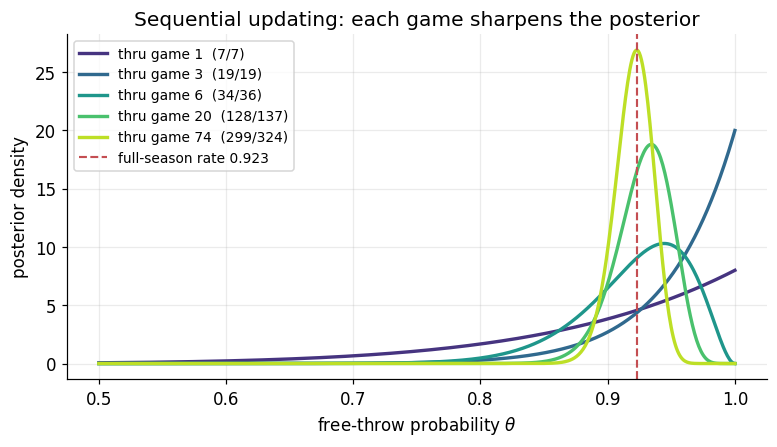

In [12]:
# Figure: the posterior tightening around ~0.92 as more games accumulate.
ths = np.linspace(0.5, 1.0, 600)
fig, ax = plt.subplots()
cmap = plt.cm.viridis(np.linspace(0.15, 0.9, len(checkpoints)))
for g, col in zip(checkpoints, cmap):
    row = curry.iloc[g - 1]
    kk, nn = int(row['cum_ft']), int(row['cum_fta'])
    pj = stats.beta(1 + kk, 1 + nn - kk)
    ax.plot(ths, pj.pdf(ths), color=col, lw=2.2, label=f'thru game {g}  ({kk}/{nn})')
ax.axvline(kf / nf, color=RED, ls='--', lw=1.4, label=fr'full-season rate {kf/nf:.3f}')
ax.set_xlabel(r'free-throw probability $\theta$'); ax.set_ylabel('posterior density')
ax.set_title('Sequential updating: each game sharpens the posterior')
ax.legend(loc='upper left', fontsize=9); plt.tight_layout(); plt.show()


**Read-out.** Belief moves with evidence: after the opening 7/7 the posterior is wide
($\mathrm{Beta}(8,1)$, mean $0.889$, sd $0.099$); by the full season $\mathrm{Beta}(300,26)$
has mean $0.920$ and sd $0.015$ — six times tighter. The shuffled-order update lands on
the **identical** $\mathrm{Beta}(300,26)$, confirming order invariance: the posterior
depends on the data only through the totals, not the path taken to them.


## Section 1.5 — Prior Sensitivity: How Much Does the Prior Matter?

The standard worry about Bayesian inference is **prior sensitivity**. The clean way to
quantify it: a $\mathrm{Beta}(a_0,b_0)$ prior carries **strength** $n_0=a_0+b_0$
(pseudo-observations), and the posterior mean is a precision-weighted average of the
prior mean and the data MLE,

$$\mathbb{E}[\theta\mid X] = w\,\hat\theta + (1-w)\,\theta_{\text{prior}},
\qquad w = \frac{n}{n + n_0}.$$

So the prior's influence is governed by $n_0$ **relative to** $n$ — not by "small $n$"
alone. We pit four priors against Curry's data at two sample sizes:

| prior | $\mathrm{Beta}(a_0,b_0)$ | mean | $n_0$ | rationale |
|-------|--------------------------|------|-------|-----------|
| Flat | $\mathrm{Beta}(1,1)$ | 0.50 | 2 | no information |
| Jeffreys | $\mathrm{Beta}(0.5,0.5)$ | 0.50 | 1 | reference / invariant |
| Skeptical | $\mathrm{Beta}(28,8)$ | 0.78 | 36 | league-average shooter |
| Career | $\mathrm{Beta}(3937,384)$ | 0.91 | 4321 | Curry's pre-2023-24 record |


In [13]:
# Build the four priors; the Career prior IS Curry's real pre-2023-24 free-throw record.
career = pd.read_csv(url('nba_freethrow_career.csv'))
crow = career[career['player'] == 'Stephen Curry'].iloc[0]
prior_mk = int(crow['career_ft'])  - kf      # career makes BEFORE 2023-24
prior_at = int(crow['career_fta']) - nf      # career attempts BEFORE 2023-24
priors = {
    'Flat (.50)':      (1.0, 1.0),
    'Jeffreys (.50)':  (0.5, 0.5),
    'Skeptical (.78)': (28.0, 8.0),
    'Career (.91)':    (float(prior_mk), float(prior_at - prior_mk)),
}
print(f"Career prior = Curry's pre-2023-24 record: {prior_mk}/{prior_at} "
      f"-> Beta({prior_mk}, {prior_at - prior_mk}), mean {prior_mk/prior_at:.4f}\n")

for label, (kk, nn) in [('EARLY (34/36)', (k, n)), ('FULL season (299/324)', (kf, nf))]:
    print(f'{label}: MLE = {kk/nn:.3f}')
    print(f'  {"prior":16s} {"n0":>6s} {"w":>6s} {"post.mean":>10s} {"post.sd":>8s} {"P(>.90)":>8s}')
    for name, (pa, pb) in priors.items():
        n0 = pa + pb
        w = nn / (nn + n0)
        pj = stats.beta(pa + kk, pb + (nn - kk))
        print(f'  {name:16s} {n0:6.0f} {w:6.3f} {pj.mean():10.4f} {pj.std():8.4f} {pj.sf(0.90):8.3f}')
    print()
print('Flat/Jeffreys (n0~1-2): w~1, invisible at any n. Skeptical (n0=36): drags the hot')
print('34/36 down to 0.861 (w=.5) -- defensible for an UNKNOWN shooter, not for Curry --')
print('and is correctly overwhelmed by the full season (w=.9). Career (n0=4321) dominates')
print('throughout, pinning sd ~0.004: a STRONG prior earns its weight via real evidence.')


Career prior = Curry's pre-2023-24 record: 3937/4321 -> Beta(3937, 384), mean 0.9111

EARLY (34/36): MLE = 0.944
  prior                n0      w  post.mean  post.sd  P(>.90)
  Flat (.50)            2  0.947     0.9211   0.0432    0.730
  Jeffreys (.50)        1  0.973     0.9324   0.0407    0.809
  Skeptical (.78)      36  0.500     0.8611   0.0405    0.169
  Career (.91)       4321  0.008     0.9114   0.0043    0.995

FULL season (299/324): MLE = 0.923
  prior                n0      w  post.mean  post.sd  P(>.90)
  Flat (.50)            2  0.994     0.9202   0.0150    0.906
  Jeffreys (.50)        1  0.997     0.9215   0.0149    0.919
  Skeptical (.78)      36  0.900     0.9083   0.0152    0.720
  Career (.91)       4321  0.070     0.9119   0.0042    0.997

Flat/Jeffreys (n0~1-2): w~1, invisible at any n. Skeptical (n0=36): drags the hot
34/36 down to 0.861 (w=.5) -- defensible for an UNKNOWN shooter, not for Curry --
and is correctly overwhelmed by the full season (w=.9). Career (n0

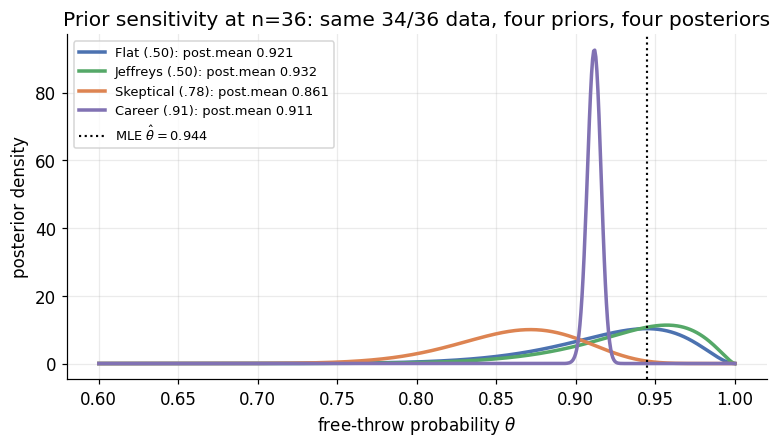

In [14]:
# Figure: four posteriors for the SAME early data (34/36) -- the prior visibly steers them.
ths = np.linspace(0.6, 1.0, 600)
fig, ax = plt.subplots()
cols = {'Flat (.50)': BLUE, 'Jeffreys (.50)': GREEN,
        'Skeptical (.78)': ORANGE, 'Career (.91)': PURPLE}
for name, (pa, pb) in priors.items():
    pj = stats.beta(pa + k, pb + (n - k))
    ax.plot(ths, pj.pdf(ths), color=cols[name], lw=2.3,
            label=f'{name}: post.mean {pj.mean():.3f}')
ax.axvline(phat, color='k', ls=':', lw=1.4, label=fr'MLE $\hat\theta={phat:.3f}$')
ax.set_xlabel(r'free-throw probability $\theta$'); ax.set_ylabel('posterior density')
ax.set_title('Prior sensitivity at n=36: same 34/36 data, four priors, four posteriors')
ax.legend(loc='upper left', fontsize=8.5); plt.tight_layout(); plt.show()


**Read-out.** With only $n=36$ shots the prior is clearly visible: the skeptical
$\mathrm{Beta}(28,8)$ pulls the estimate from the MLE $0.944$ down to $0.861$ (it has
$w=0.5$, equal footing with the data), while the career prior pins it at $0.911$ with
sd $\approx 0.004$. By the full season ($n=324$) the data weight rises to $w=0.90$ for
the skeptical prior and it is overwhelmed. **Lesson:** set $n_0$ to the prior *evidence
you actually have* — the career prior is backed by 4321 real attempts and earns its
weight; generic skepticism does not. As $n$ grows, all reasonable priors converge.


## Section 1.6 — Likelihood-Based Inference and the Likelihood Principle

The **likelihood** $L(\theta)=\prod_i f(x_i\mid\theta)$ is the engine of *both*
frequentist (the MLE) and Bayesian (the posterior $\propto L\times\text{prior}$)
inference. The **likelihood principle** asserts that all the evidence the data carry
about $\theta$ is in $L$: two datasets with **proportional** likelihoods support the
same inference, *regardless of the sampling plan*.

The textbook stress-test: 3 heads in 10 flips arising from two different designs.

* **Binomial** — flip exactly $n=10$ times, observe $h=3$:
  $L_{\text{Bin}}(p)=\binom{10}{3}p^3(1-p)^7$.
* **Negative binomial** — flip *until* $h=3$ heads, which takes $t=10$ flips:
  $L_{\text{NB}}(p)=\binom{9}{2}p^3(1-p)^7$.

The two differ only by a constant $\binom{10}{3}/\binom{9}{2}=120/36$ — so they are
**proportional**, and a Bayesian (or a likelihoodist) reaches the *same* posterior. A
frequentist $p$-value, which sums over the unobserved sample space, would differ.


In [15]:
# Likelihood principle: binomial vs negative-binomial sampling, identical data (3 heads, 10 flips).
ps = np.linspace(1e-4, 1 - 1e-4, 100_001)
L_bin = comb(10, 3) * ps**3 * (1 - ps)**7      # flip exactly n=10
L_nb  = comb(9, 2)  * ps**3 * (1 - ps)**7      # flip until h=3 heads (t=10)
ratio = L_bin / L_nb
print(f'Normalizing constants: C(10,3) = {comb(10,3):.0f}   C(9,2) = {comb(9,2):.0f}')
print(f'  MLE argmax_p L:   binomial {ps[np.argmax(L_bin)]:.3f}   neg-binomial {ps[np.argmax(L_nb)]:.3f}')
print(f'  L_bin / L_nb is CONSTANT in p: range over the grid = {np.ptp(ratio):.2e}'
      f'  (= C(10,3)/C(9,2) = {comb(10,3)/comb(9,2):.3f})')
print('  Proportional likelihoods -> identical evidence about p. A Bayesian with a')
print('  Beta(a,b) prior gets Beta(a+3, b+7) EITHER WAY; the sampling plan is irrelevant.')


Normalizing constants: C(10,3) = 120   C(9,2) = 36
  MLE argmax_p L:   binomial 0.300   neg-binomial 0.300
  L_bin / L_nb is CONSTANT in p: range over the grid = 2.22e-15  (= C(10,3)/C(9,2) = 3.333)
  Proportional likelihoods -> identical evidence about p. A Bayesian with a
  Beta(a,b) prior gets Beta(a+3, b+7) EITHER WAY; the sampling plan is irrelevant.


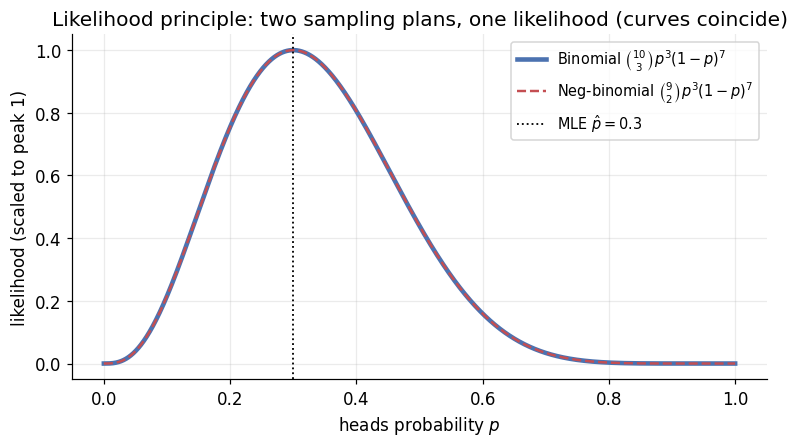

In [16]:
# Figure: the two likelihoods (each scaled to peak 1) are the SAME curve.
fig, ax = plt.subplots()
ax.plot(ps, L_bin / L_bin.max(), color=BLUE, lw=3.0, label=r'Binomial $\binom{10}{3}p^3(1-p)^7$')
ax.plot(ps, L_nb / L_nb.max(), color=RED, lw=1.6, ls='--',
        label=r'Neg-binomial $\binom{9}{2}p^3(1-p)^7$')
ax.axvline(0.3, color='k', ls=':', lw=1.2, label=r'MLE $\hat p = 0.3$')
ax.set_xlabel(r'heads probability $p$'); ax.set_ylabel('likelihood (scaled to peak 1)')
ax.set_title('Likelihood principle: two sampling plans, one likelihood (curves coincide)')
ax.legend(loc='upper right', fontsize=9.5); plt.tight_layout(); plt.show()


## Exercises

Work each before expanding the solution. These integrate the philosophical and
computational threads of the chapter (and preview Chapter 5's Bayesian machinery).


**Exercise 1 (§1.3, paradigm comparison).** A coin is flipped 20 times, yielding 14
heads. (a) Give the Normal-approximation 95% CI and the exact **Clopper–Pearson** 95%
CI for $p$. (b) With a flat $\mathrm{Beta}(1,1)$ prior, give the posterior, its mean,
and a 95% **credible** interval. (c) A scientist asks, "what is the probability that
$p>0.5$?" — answer it the Bayesian way and contrast with the frequentist test.


In [17]:
# Solution 1.
n_e, x_e = 20, 14
phat_e = x_e / n_e
# (a) frequentist
se_e = np.sqrt(phat_e * (1 - phat_e) / n_e)
ci_norm = (phat_e - 1.96*se_e, phat_e + 1.96*se_e)
ci_cp = proportion_confint(x_e, n_e, alpha=0.05, method='beta')
print(f'(a) MLE = {phat_e:.4f}')
print(f'    Normal 95% CI         : ({ci_norm[0]:.4f}, {ci_norm[1]:.4f})')
print(f'    Clopper-Pearson 95% CI: ({ci_cp[0]:.4f}, {ci_cp[1]:.4f})   (exact, asymmetric)')
# (b) Bayesian
post_e = stats.beta(1 + x_e, 1 + n_e - x_e)        # Beta(15, 7)
cred_e = post_e.ppf([0.025, 0.975])
print(f'(b) Posterior Beta(15, 7): mean {post_e.mean():.4f}, '
      f'95% credible interval ({cred_e[0]:.4f}, {cred_e[1]:.4f})')
print(f'    Posterior mean 0.6818 is shrunk from the MLE 0.70 toward the prior mean 0.5.')
# (c) P(p > 0.5)
print(f'(c) Bayesian:  P(p > 0.5 | data) = {post_e.sf(0.5):.4f}  (a direct answer)')
z_e = (phat_e - 0.5) / np.sqrt(0.5*0.5/n_e)
print(f'    Frequentist: test H0: p<=0.5 -> z = {z_e:.4f}, p-value = {stats.norm.sf(z_e):.4f}')
print('    The Bayesian answers the question asked; the frequentist reports evidence')
print('    AGAINST p<=0.5, which is related but not the same quantity.')


(a) MLE = 0.7000
    Normal 95% CI         : (0.4992, 0.9008)
    Clopper-Pearson 95% CI: (0.4572, 0.8811)   (exact, asymmetric)
(b) Posterior Beta(15, 7): mean 0.6818, 95% credible interval (0.4782, 0.8541)
    Posterior mean 0.6818 is shrunk from the MLE 0.70 toward the prior mean 0.5.
(c) Bayesian:  P(p > 0.5 | data) = 0.9608  (a direct answer)
    Frequentist: test H0: p<=0.5 -> z = 1.7889, p-value = 0.0368
    The Bayesian answers the question asked; the frequentist reports evidence
    AGAINST p<=0.5, which is related but not the same quantity.


**Exercise 2 (§1.4 / §1.5).** Suppose a fan had used Curry's **career** prior
$\mathrm{Beta}(3937,384)$ instead of a flat prior, and saw only the opening **7/7**.
Compute the posterior mean and the data weight $w$. Why does the blistering 7/7 barely
move the estimate?


In [18]:
# Solution 2.
pa, pb = float(prior_mk), float(prior_at - prior_mk)   # career prior Beta(3937, 384)
kk, nn = 7, 7
n0 = pa + pb
w = nn / (nn + n0)
post_c = stats.beta(pa + kk, pb + (nn - kk))
print(f'Career prior Beta({pa:.0f}, {pb:.0f}): n0 = {n0:.0f}, prior mean {pa/n0:.4f}')
print(f'After 7/7: data weight w = n/(n+n0) = {nn}/{nn+n0:.0f} = {w:.4f}')
print(f'  posterior mean = {post_c.mean():.4f}  (essentially the prior mean {pa/n0:.4f})')
print(f'  A perfect 7/7 carries weight {w:.3f} against 4321 prior attempts -- a drop in')
print(f'  the bucket. Strong, evidence-backed priors resist small samples by design.')


Career prior Beta(3937, 384): n0 = 4321, prior mean 0.9111
After 7/7: data weight w = n/(n+n0) = 7/4328 = 0.0016
  posterior mean = 0.9113  (essentially the prior mean 0.9111)
  A perfect 7/7 carries weight 0.002 against 4321 prior attempts -- a drop in
  the bucket. Strong, evidence-backed priors resist small samples by design.


**Exercise 3 (§1.1).** Verify numerically that a probability assignment violating
non-negativity (Axiom 1) or normalization (Axiom 2) is rejected by the
`DiscreteProbabilitySpace` constructor.


In [19]:
# Solution 3.
for bad, why in [([0.5, 0.6, -0.1], 'negative probability (Axiom 1)'),
                 ([0.3, 0.3, 0.3], 'sums to 0.9 != 1 (Axiom 2)')]:
    try:
        DiscreteProbabilitySpace(['a', 'b', 'c'], bad)
        print(f'  {bad}: accepted (unexpected!)')
    except ValueError as e:
        print(f'  {bad}: rejected -> {e}')
print('  Both invalid assignments are caught: the axioms are enforced at construction.')


  [0.5, 0.6, -0.1]: rejected -> Axiom 1 violated: P(c) = -0.1 < 0
  [0.3, 0.3, 0.3]: rejected -> Axiom 2 violated: total probability 0.8999999999999999 != 1
  Both invalid assignments are caught: the axioms are enforced at construction.


## Section 1.7 — Summary & connections forward

**The arc.** Kolmogorov's axioms are the universal grammar of probability; everyone
accepts them, yet they do not fix *meaning*. The **frequentist** reads probability as
long-run frequency (LLN), the **Bayesian** as degree of belief (Bayes' theorem), the
**likelihoodist** as relative evidence. Those readings produce different inference: a
**confidence interval** (a statement about a procedure) vs a **credible interval** (a
statement about the parameter). On Curry's free throws we saw both, watched the
Bayesian posterior **update sequentially** and order-invariantly, and quantified
**prior sensitivity** through the data weight $w=n/(n+n_0)$.

| Concept | Key object | This chapter's demonstration |
|---------|-----------|------------------------------|
| Kolmogorov's axioms | $P\ge0$, $P(\Omega)=1$, additivity | fair-die check; Dutch-book coherence |
| Frequentist probability | $\lim_n (\#E)/n$ | coin: relfreq $\to 0.6$ (LLN) |
| Bayesian probability | $P(\theta\mid X)\propto L\cdot\pi$ | disease test: $1\%\to8.76\%$ |
| Confidence interval | random interval, fixed $\theta$ | Curry Wald/Wilson/Clopper–Pearson |
| Credible interval | $P(\theta\in[L,U]\mid X)=0.95$ | Beta(35,3): $[0.818,0.983]$ |
| Conjugate update | $\mathrm{Beta}(a{+}k,\,b{+}n{-}k)$ | sequential, Beta(8,1)$\to$Beta(300,26) |
| Prior strength | $w=n/(n+n_0)$ | four priors $\times$ early/full season |
| Likelihood principle | proportional $L\Rightarrow$ same inference | binomial $\equiv$ neg-binomial |

**Forward.** This conceptual base feeds the rest of the course. **Chapter 2** builds
the **Monte Carlo** machinery the LLN here justifies (the frequency-converges-to-truth
idea *is* simulation). **Chapters 3–4** develop the **frequentist** pipeline
(maximum likelihood, sampling distributions, confidence intervals, the bootstrap) —
making the "fixed parameter, random interval" view operational. **Chapter 5** develops
**Bayesian** inference in full (priors, posteriors, conjugacy, and MCMC for the
non-conjugate models) — turning the Beta–Binomial sketch here into a general method.
Keep the central lesson in view: *choose the paradigm that answers your question*, and
know exactly what your interval is claiming.
